In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
df=pd.read_csv('Breast_Cancer.csv')
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [153]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [154]:
df.drop(columns=['Race','Marital Status','Age','differentiate'],inplace=True)

In [155]:
df.head()

,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,T1,N1,IIA,3,Regional,4,Positive,Positive,24,1,60,Alive
1,T2,N2,IIIA,2,Regional,35,Positive,Positive,14,5,62,Alive
2,T3,N3,IIIC,2,Regional,63,Positive,Positive,14,7,75,Alive
3,T1,N1,IIA,3,Regional,18,Positive,Positive,2,1,84,Alive
4,T2,N1,IIB,3,Regional,41,Positive,Positive,3,1,50,Alive


In [156]:
df['A Stage']=df['A Stage'].map({'Regional':0,'Distant':1})
df['Progesterone Status']=df['Progesterone Status'].map({'Positive':1,'Negative':0})
df['Estrogen Status']=df['Estrogen Status'].map({'Positive':1,'Negative':0})
df['Status']=df['Status'].map({'Alive':1,'Dead':0})

In [157]:
df.head()

,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,T1,N1,IIA,3,0,4,1,1,24,1,60,1
1,T2,N2,IIIA,2,0,35,1,1,14,5,62,1
2,T3,N3,IIIC,2,0,63,1,1,14,7,75,1
3,T1,N1,IIA,3,0,18,1,1,2,1,84,1
4,T2,N1,IIB,3,0,41,1,1,3,1,50,1


In [158]:
df['T Stage ']=df['T Stage '].map({'T1':0,'T2':1,'T3':2,'T4':3})
df['N Stage']=df['N Stage'].map({'N1':0,'N2':1,'N3':2})

In [159]:
df['6th Stage']=df['6th Stage'].map({'IIA':2,'IIB':2,'IIIA':3,'IIIB':3,'IIIC':3})

In [160]:
df.head()

,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,0,0,2,3,0,4,1,1,24,1,60,1
1,1,1,3,2,0,35,1,1,14,5,62,1
2,2,2,3,2,0,63,1,1,14,7,75,1
3,0,0,2,3,0,18,1,1,2,1,84,1
4,1,0,2,3,0,41,1,1,3,1,50,1


In [161]:
df['Grade'].value_counts()

Grade
2                        2351
3                        1111
1                         543
 anaplastic; Grade IV      19
Name: count, dtype: int64

In [162]:
df['Grade']=df['Grade'].replace(' anaplastic; Grade IV',4)  

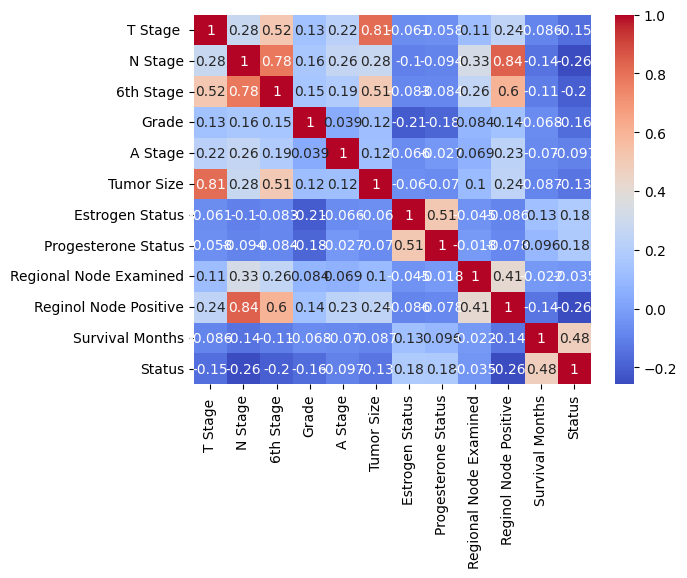

<Figure size 1000x1000 with 0 Axes>

In [163]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.figure(figsize=(10,10))
plt.show()

In [164]:
df['Status'].value_counts()

Status
1    3408
0     616
Name: count, dtype: int64

In [172]:
df.tail(10)

,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4014,2,0,3,2,0,68,1,1,22,2,86,1
4015,1,1,3,2,0,40,1,1,4,4,68,1
4016,1,0,2,1,0,50,1,1,29,2,52,1
4017,1,0,2,2,0,28,0,0,2,1,19,0
4018,0,0,2,2,0,10,1,1,11,1,70,1
4019,0,0,2,2,0,9,1,1,1,1,49,1
4020,1,1,3,2,0,46,1,1,14,8,69,1
4021,1,0,2,2,0,22,1,0,11,3,69,1
4022,1,0,2,2,0,44,1,1,11,1,72,1
4023,1,0,2,2,0,30,1,1,7,2,100,1


In [171]:
df.nunique()

T Stage                     4
N Stage                     3
6th Stage                   2
Grade                       4
A Stage                     2
Tumor Size                110
Estrogen Status             2
Progesterone Status         2
Regional Node Examined     54
Reginol Node Positive      38
Survival Months           107
Status                      2
dtype: int64

In [165]:
X=df.drop('Status',axis=1)
y=df['Status']

In [166]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [167]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [168]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [169]:
models={
    'Adaboost':AdaBoostClassifier(),
    'Random forest':RandomForestClassifier(),
    'Xgboost':XGBClassifier()
}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    print(f"{name}:\n")
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print(accuracy_score(y_test,y_pred))

Adaboost:

              precision    recall  f1-score   support

           0       0.79      0.53      0.64       120
           1       0.92      0.98      0.95       685

    accuracy                           0.91       805
   macro avg       0.86      0.75      0.79       805
weighted avg       0.90      0.91      0.90       805

[[ 64  56]
 [ 17 668]]
0.9093167701863354
Random forest:

              precision    recall  f1-score   support

           0       0.76      0.53      0.62       120
           1       0.92      0.97      0.95       685

    accuracy                           0.90       805
   macro avg       0.84      0.75      0.78       805
weighted avg       0.90      0.90      0.90       805

[[ 63  57]
 [ 20 665]]
0.9043478260869565
Xgboost:

              precision    recall  f1-score   support

           0       0.71      0.51      0.59       120
           1       0.92      0.96      0.94       685

    accuracy                           0.90       805
   macr

In [170]:
import pickle
pickle.dump(model,open('breast_cancer_model.pkl','wb'))
pickle.dump(scaler,open('breast_cancer_scaler.pkl','wb'))
print("Model saved successfully.")

Model saved successfully.
